<div style="background:#FF0000; padding:6px; border:0px solid #d0d7de; border-radius:0px">

## Problem Defined

#### - Predict the wind power generated at a farm in Brazil using a multiple linear regression and a random forest model 

<div style="background:#FF0000; padding:6px; border:0px solid #d0d7de; border-radius:0px">

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

<div style="background:#FF0000; padding:6px; border:0px solid #d0d7de; border-radius:0px">

## Data Imported

In [2]:
#loads the wind data 
df_wind = pd.read_csv('wind_gen.csv')

In [3]:
df_wind.head()

,Date,Temperature,Relative Humidity,Wind Speed,Precipitation,Pressure,Generated
0,01/01/2016,28.86,63.50,1.16,0.0,1000.34,16.317583
1,02/01/2016,29.58,60.75,1.50,0.0,1000.30,29.661333
2,03/01/2016,29.26,74.75,1.56,0.0,1000.19,33.105792
3,04/01/2016,29.20,64.00,2.66,0.0,1000.19,29.738250
4,05/01/2016,29.02,63.75,1.83,0.0,1000.89,29.993500


<div style="background:#FF0000; padding:6px; border:0px solid #d0d7de; border-radius:0px">

## Exploratory Data Analysis (EDA)

<div style="background:#c8f6ff; padding:6px; border:0px solid #d0d7de; border-radius:0px">

### Check Shape

In [4]:
#checking shape of dataset
df_wind.shape

(2557, 7)

<div style="background:#c8f6ff; padding:6px; border:0px solid #d0d7de; border-radius:0px">

### Check Data Type

In [5]:
#check data types of variables 
df_wind.dtypes

Date                  object
Temperature          float64
Relative Humidity    float64
Wind Speed           float64
Precipitation        float64
Pressure             float64
Generated            float64
dtype: object

#### - Convert date from object to datetime64 so can work with the timeseries data in python

In [6]:
#change date variable from object to datetime so data can be manipulated in python

df_wind['Date'] = pd.to_datetime(df_wind['Date'], format='%d/%m/%Y')

In [7]:
#check datatype again

df_wind.dtypes

Date                 datetime64[ns]
Temperature                 float64
Relative Humidity           float64
Wind Speed                  float64
Precipitation               float64
Pressure                    float64
Generated                   float64
dtype: object

In [8]:
#explore the minimum and maximum date that we have

#minimum date
print(df_wind['Date'].min())

# print the maximum date
print(df_wind['Date'].max())

2016-01-01 00:00:00
2022-12-31 00:00:00


In [9]:
#get a column for months
df_wind['month'] = df_wind['Date'].dt.month

<div style="background:#c8f6ff; padding:6px; border:0px solid #d0d7de; border-radius:0px">

### Check for Missing Values

In [10]:
#check if we have any missing data

df_wind.isna().sum()

Date                 0
Temperature          0
Relative Humidity    0
Wind Speed           0
Precipitation        0
Pressure             0
Generated            0
month                0
dtype: int64

<div style="background:#c8f6ff; padding:6px; border:0px solid #d0d7de; border-radius:0px">

### Target Variable Distribution

- #### Positively skewed distribution

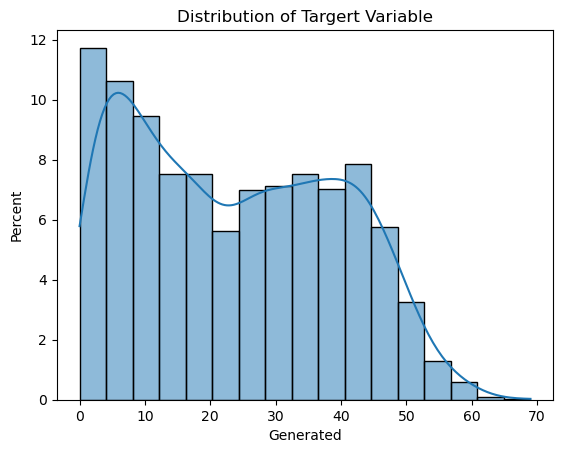

In [11]:
# make the histogram
sns.histplot(df_wind['Generated'], kde=True, stat='percent')

plt.title("Distribution of Targert Variable")

plt.show()

<div style="background:#FF0000; padding:6px; border:0px solid #d0d7de; border-radius:0px">

## Feature Engineering and Selection

<div style="background:#c8f6ff; padding:6px; border:0px solid #d0d7de; border-radius:0px">

### Correlation Matrix

#### - No predictor feature taken out since no features are highly correlated with eachother

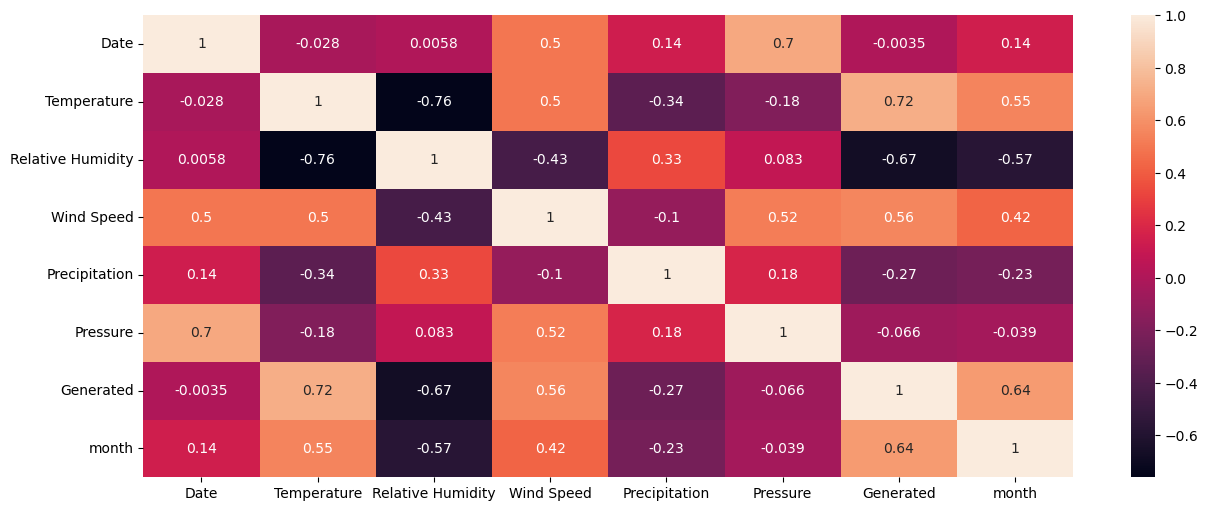

In [13]:
corr = df_wind.corr()

plt.figure(figsize=(15, 6))

sns.heatmap(corr,annot=True)

plt.show()

<div style="background:#c8f6ff; padding:6px; border:0px solid #d0d7de; border-radius:0px">

### Statistical Summary

In [14]:
df_wind.describe()

,Date,Temperature,Relative Humidity,Wind Speed,Precipitation,Pressure,Generated,month
count,2557,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000
mean,2019-07-02 00:00:00,27.328398,70.875810,1.432836,2.358066,1003.205704,23.624576,6.522487
min,2016-01-01 00:00:00,23.420000,24.000000,0.000000,0.000000,996.370000,0.000000,1.000000
25%,2017-10-01 00:00:00,26.440000,63.000000,0.680000,0.000000,1000.280000,9.061500,4.000000
50%,2019-07-02 00:00:00,27.354167,70.875810,1.330000,0.000000,1001.800000,22.545750,7.000000
75%,2021-04-01 00:00:00,28.220000,78.916667,2.033333,2.358066,1007.050000,37.037042,10.000000
max,2022-12-31 00:00:00,32.880000,97.750000,4.150000,102.600000,1014.195833,68.981000,12.000000
std,NaN,1.212769,11.141901,0.907790,6.848844,3.934474,15.747324,3.449499


<div style="background:#c8f6ff; padding:6px; border:0px solid #d0d7de; border-radius:0px">

### Split Data

#### - 60% training, 20% validation, 20% testing

In [17]:
df_wind.columns

Index(['Date', 'Temperature', 'Relative Humidity', 'Wind Speed',
       'Precipitation', 'Pressure', 'Generated', 'month'],
      dtype='object')

In [18]:
X = df_wind[['Temperature', 'Relative Humidity', 'Wind Speed',
       'Precipitation', 'Pressure', 'month']]

y = df_wind['Generated']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_train, y_train, test_size=0.25, random_state=42,shuffle=False)

<div style="background:#FF0000; padding:6px; border:0px solid #d0d7de; border-radius:0px">

## Model Selection and Training

<div style="background:#c8f6ff; padding:6px; border:0px solid #d0d7de; border-radius:0px">

### Random Forest

In [17]:
#initialize model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
rf_r2_train = r2_score(y_train, rf.predict(X_train))

rf_rmse_train = root_mean_squared_error(y_train, rf.predict(X_train))

print(f'Training Set R2:{rf_r2_train}')
print(f'Training Set RMSE:{rf_rmse_train}')

Training Set R2:0.9622864797526274
Training Set RMSE:3.026084871828641


<div style="background:#FFA500; padding:6px; border:0px solid #d0d7de; border-radius:0px">

##### Hyperparameter Tuning

In [19]:
param_grid = {
    'n_estimators': np.arange(50, 301, 50),
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': np.arange(2, 11),
    'min_samples_leaf': np.arange(1, 6),
}

tscv = TimeSeriesSplit(n_splits=5)

#time series s
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, n_iter=20, cv=tscv, n_jobs=-1, random_state=42)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Print the best parameters
print("Best parameters found: ", random_search.best_params_)

Best parameters found:  {'n_estimators': np.int64(200), 'min_samples_split': np.int64(3), 'min_samples_leaf': np.int64(5), 'max_depth': 5}


<div style="background:#FFA500; padding:6px; border:0px solid #d0d7de; border-radius:0px">

##### Validation Set

In [20]:
hpt_rf = random_search.best_estimator_

# calculate the scores for the training set 
val_rf_r2_train = r2_score(y_val, hpt_rf.predict(X_val))
val_rf_rmse_train = root_mean_squared_error(y_val, hpt_rf.predict(X_val))
print(f"Valdation R2: {val_rf_r2_train:.4f}")
print(f"Valdation RMSE: {val_rf_rmse_train:.4f}")

Valdation R2: 0.7594
Valdation RMSE: 7.5473


<div style="background:#c8f6ff; padding:6px; border:0px solid #d0d7de; border-radius:0px">

### Multiple Linear Regression Model 

In [22]:
#initialize model
lr = make_pipeline(StandardScaler(), LinearRegression())
lr.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [23]:
lr_r2_train = r2_score(y_train, lr.predict(X_train))

lr_rmse_train = root_mean_squared_error(y_train, lr.predict(X_train))

print(f'Training Set R2:{lr_r2_train}')
print(f'Training Set RMSE:{lr_rmse_train}')

Training Set R2:0.6727223165960845
Training Set RMSE:8.914372228824233


<div style="background:#FFA500; padding:6px; border:0px solid #d0d7de; border-radius:0px">

##### Validation Set

In [27]:
lr_r2_val = r2_score(y_val, lr.predict(X_val))

lr_rmse_val = root_mean_squared_error(y_val, lr.predict(X_val))

print(f'Validation Set R2:{lr_r2_val}')
print(f'Validation Set RMSE:{lr_rmse_val}')

Validation Set R2:0.6685308788774256
Validation Set RMSE:8.858169817770822


<div style="background:#FF0000; padding:6px; border:0px solid #d0d7de; border-radius:0px">

## Model Testing

#### - Since random test performed bettern with the validation select, it will be deployed for testing

In [28]:
y_hat = hpt_rf.predict(X_test)

# calculate the scores for the test set 
hpt_rf_r2_test = r2_score(y_test, y_hat)
hpt_rf_rmse_test = root_mean_squared_error(y_test, y_hat)

print(f"Training R2: {hpt_rf_r2_test:.4f}")
print(f"Training RMSE: {hpt_rf_rmse_test:.4f}")

Training R2: 0.8064
Training RMSE: 7.0838


<div style="background:#FF0000; padding:6px; border:0px solid #d0d7de; border-radius:0px">

## Model Evaluation

<div style="background:#c8f6ff; padding:6px; border:0px solid #d0d7de; border-radius:0px">

### Observations vs. Predictions

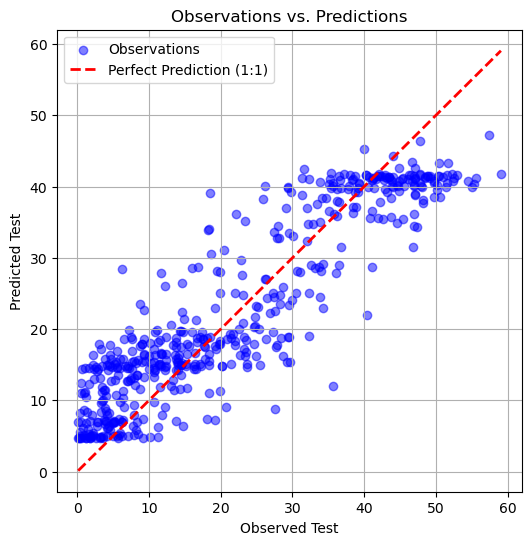

In [33]:
#Create the scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test,y_hat, alpha=0.5, color='blue', label='Observations')

#1:1 line
min_val = min(y_test.min(), y_test.min())
max_val = max(y_test.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (1:1)')


plt.xlabel('Observed Test')
plt.ylabel('Predicted Test')
plt.title('Observations vs. Predictions')
plt.legend()
plt.grid(True)
plt.show()

<div style="background:#c8f6ff; padding:6px; border:0px solid #d0d7de; border-radius:0px">

### Residual

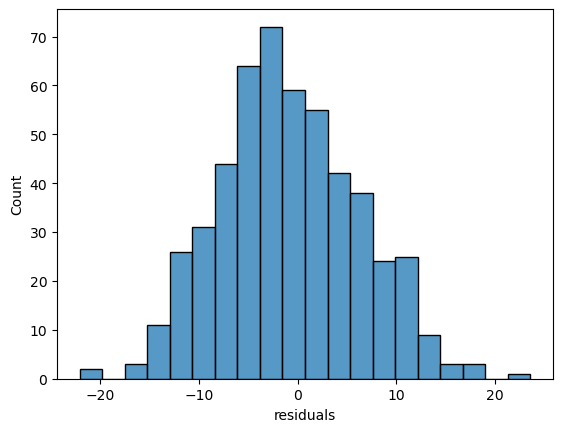

In [34]:
residuals = y_test - y_hat

# plot the histogram of residuals 

# make the histrogram
sns.histplot(x = residuals)
# label the x-axis
plt.xlabel('residuals')
# show the plot
plt.show()

<div style="background:#c8f6ff; padding:6px; border:0px solid #d0d7de; border-radius:0px">
    
### Feature Importance 

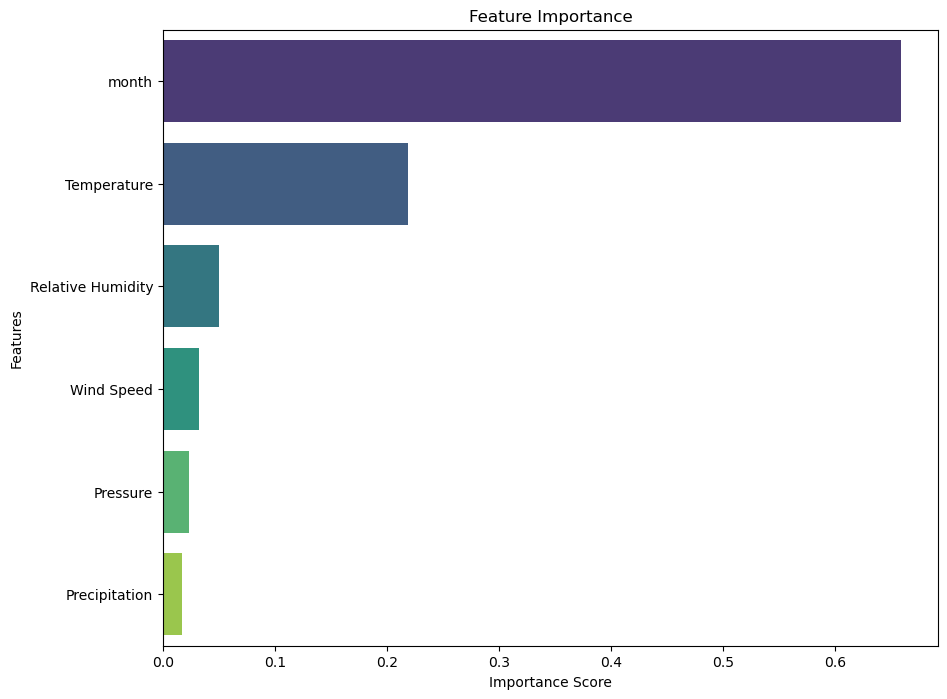

,Feature,Importance
5,month,0.659173
0,Temperature,0.218471
1,Relative Humidity,0.050167
2,Wind Speed,0.032109
4,Pressure,0.023193
3,Precipitation,0.016888


In [30]:
#Get feature importances from the trained model
tree_importances = hpt_rf.feature_importances_
feature_names = X.columns

#dreate a DataFrame for plotting 
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': tree_importances})

#dort it to make the dataframe intuitive when you plot it 
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

#Plot the feature importances
plt.figure(figsize=(10, 8))


sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)


plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

# show the plot
plt.show()

# Display the top features
display(feature_importance_df.head(10))